# NBD-Bass ハイブリッドモデル: パチンコ参加者動態の閾値効果補正

## 動機

従来の Bass 拡張モデル（`Pachinko_3State_P1tP2t`）では **p₁ と p₂ の分離** が困難だった。原因仮説:

> 「年1回以上プレイ」の閾値は、**真の離脱**と**低頻度化による閾値下落（閾値効果）**を区別できない。見かけの p₂ は両者の合成。

## NBD 仮説

個人の年間遊戯回数 $X_i$ は NBD（Ehrenberg-Goodhardt）で記述:

$$X_i \mid \lambda_i \sim \text{Poisson}(\lambda_i), \quad \lambda_i \sim \text{Gamma}(r, \alpha)$$

条件付きビン分布:

$$P(X=k \mid r,\alpha) = \binom{r+k-1}{k}\left(\frac{\alpha}{\alpha+1}\right)^r \left(\frac{1}{\alpha+1}\right)^k$$

$$\hat{p}_k = \frac{\sum_{x \in \text{bin}_k} P(X=x)}{1 - P(X=0)}$$

## ビン代表値

| ビン | 頻度範囲 | 範囲 (整数) |
|---|---|---|
| heavy | 週2回以上 | X ≥ 104 |
| middle | 月4-5回 | 48 ≤ X < 104 |
| lmiddle | 月1-3回 | 12 ≤ X < 48 |
| light (13+) | 年4-5回 | 4 ≤ X < 12 |
| rare (13+) | 年1-2回 | 1 ≤ X < 4 |
| light (08-12) | 年5-6回 | 5 ≤ X < 12 |
| rare (08-12) | 年2-3回 | 2 ≤ X < 5 |

In [1]:
ENV["GKS_ENCODING"] = "utf8"
using Turing, Distributions, DataFrames, CSV
using Plots, StatsPlots, Statistics, Printf, Random, SpecialFunctions
gr(fontfamily="PlemolJP-Text")
Random.seed!(20260415);

In [2]:
# 頻度データ読み込み
df_freq = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\data\パチンコ頻度データ.csv",
                   DataFrame; stripwhitespace=true)
rename!(df_freq, names(df_freq) .=> [:年, :heavy, :middle, :lmiddle,
                                      :light_old, :rare_old, :light_new, :rare_new])
println(df_freq)

# 統一した light/rare に変換（データのある側を使う）
df_freq.light = coalesce.(df_freq.light_new, df_freq.light_old)
df_freq.rare  = coalesce.(df_freq.rare_new,  df_freq.rare_old)
# ビン定義（年ごとに異なる）
df_freq.is_post2013 = df_freq.年 .>= 2013

10×8 DataFrame
 Row │ 年     heavy    middle   lmiddle  light_old    rare_old     light_new    rare_new    
     │ Int64  Float64  Float64  Float64  Float64?     Float64?     Float64?     Float64?    
─────┼──────────────────────────────────────────────────────────────────────────────────────
   1 │  2008    0.187    0.292    0.246        0.117        0.158  missing      missing     
   2 │  2011    0.228    0.205    0.246        0.124        0.197  missing      missing     
   3 │  2012    0.239    0.253    0.234        0.1          0.174  missing      missing     
   4 │  2013    0.223    0.256    0.237  missing      missing            0.094        0.19
   5 │  2014    0.228    0.255    0.264  missing      missing            0.091        0.162
   6 │  2015    0.243    0.253    0.237  missing      missing            0.096        0.171
   7 │  2016    0.277    0.242    0.254  missing      missing            0.111        0.116
   8 │  2018    0.262    0.272    0.226  missing      missing

10-element BitVector:
 0
 0
 0
 1
 1
 1
 1
 1
 1
 1

In [3]:
# ビン範囲 (X_lo, X_hi) — X_hi は含まない
bins_post = [(104, 10_000), (48, 104), (12, 48), (4, 12), (1, 4)]   # 2013+
bins_pre  = [(104, 10_000), (48, 104), (12, 48), (5, 12), (2, 5)]   # 2008-2012
# ビン順: heavy, middle, lmiddle, light, rare

# NBD P(X=k) の対数（数値安定）
function log_nbd_pmf(k::Int, r, α)
    # log P(X=k) = logΓ(r+k) - logΓ(r) - logΓ(k+1) + r·log(α/(α+1)) + k·log(1/(α+1))
    return loggamma(r + k) - loggamma(r) - loggamma(k + 1.0) +
           r * log(α / (α + 1)) + k * log(1 / (α + 1))
end

# ビン確率（P(lo ≤ X < hi)）
function nbd_bin_prob(lo::Int, hi::Int, r, α)
    # 数値的には 0..lo-1 を引く方が速いが、ビンを直接加算
    s = zero(r) * zero(α)
    k_max = min(hi - 1, lo + 500)   # heavy の上限は大きいので打ち切り
    for k in lo:k_max
        s += exp(log_nbd_pmf(k, r, α))
    end
    return s
end

# heavy は tail なので補集合で計算
function nbd_tail_prob(lo::Int, r, α, k_cap::Int=1000)
    cdf_lo = sum(exp(log_nbd_pmf(k, r, α)) for k in 0:(lo-1))
    return 1.0 - cdf_lo
end

function bin_probs_given_active(r, α, bins)
    # 各ビンの生確率
    ps = Vector{typeof(r * α)}(undef, length(bins))
    for (i, (lo, hi)) in enumerate(bins)
        if hi > 5000   # heavy = tail
            ps[i] = nbd_tail_prob(lo, r, α)
        else
            ps[i] = nbd_bin_prob(lo, hi, r, α)
        end
    end
    p0 = exp(r * log(α / (α + 1)))
    p_active = 1.0 - p0
    return ps ./ p_active, p_active, p0
end;

In [4]:
# 年ごとに NBD(r, α) を MLE（Dirichlet-Multinomial 近似で重み最小二乗）
# 観測シェアに対して log-loss を最小化
using Optim

function fit_nbd_year(shares, bins)
    function loss(params)
        r = exp(params[1]); α = exp(params[2])
        ps, _, _ = bin_probs_given_active(r, α, bins)
        # KL divergence (観測 vs 予測)
        ε = 1e-10
        return sum(shares .* log.((shares .+ ε) ./ (ps .+ ε)))
    end
    res = optimize(loss, [log(0.5), log(0.05)], NelderMead())
    r_est = exp(Optim.minimizer(res)[1])
    α_est = exp(Optim.minimizer(res)[2])
    return r_est, α_est, Optim.minimum(res)
end

# 各年の推定
results = DataFrame(年=Int[], r=Float64[], α=Float64[], E_λ=Float64[],
                    P_active=Float64[], M_lift=Float64[], KL=Float64[])
for row in eachrow(df_freq)
    shares = [row.heavy, row.middle, row.lmiddle, row.light, row.rare]
    bins = row.is_post2013 ? bins_post : bins_pre
    r, α, kl = fit_nbd_year(shares, bins)
    _, p_active, p0 = bin_probs_given_active(r, α, bins)
    push!(results, (row.年, r, α, r/α, p_active, 1.0/p_active, kl))
end
println(results)

10×7 DataFrame
 Row │ 年     r         α           E_λ      P_active  M_lift   KL         
     │ Int64  Float64   Float64     Float64  Float64   Float64  Float64    
─────┼─────────────────────────────────────────────────────────────────────
   1 │  2008  0.625865  0.0103898   60.2384  0.943003  1.06044  0.0903376
   2 │  2011  0.417705  0.00653     63.9671  0.878074  1.13886  0.0985971
   3 │  2012  0.516733  0.00729741  70.8104  0.921621  1.08504  0.0950932
   4 │  2013  0.360068  0.00542605  66.3592  0.84745   1.18001  0.0428335
   5 │  2014  0.445437  0.00647172  68.8282  0.894391  1.11808  0.0319297
   6 │  2015  0.391995  0.0053786   72.8805  0.871317  1.14769  0.0339954
   7 │  2016  0.513179  0.00620628  82.6871  0.926557  1.07926  0.00921687
   8 │  2018  0.472535  0.0058789   80.378   0.911953  1.09655  0.0325904
   9 │  2019  0.323229  0.00487806  66.2618  0.821314  1.21756  0.0199739
  10 │  2020  0.328382  0.004488    73.169   0.830825  1.20362  0.0113372


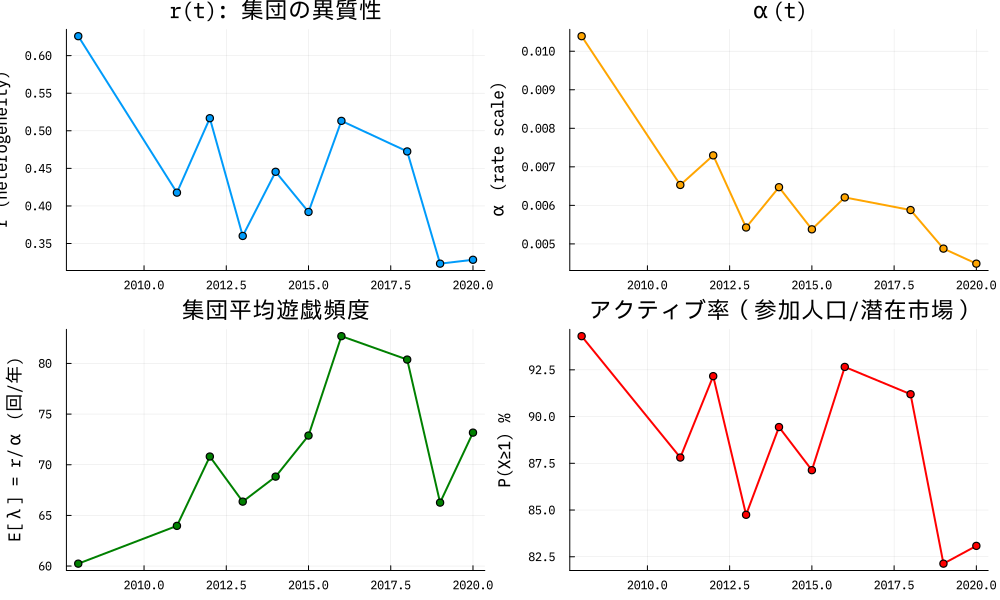

In [5]:
# r(t), α(t), E[λ](t), P(active) の時系列プロット
p1 = plot(results.年, results.r, marker=:circle, lw=2,
          ylabel="r (heterogeneity)", title="r(t): 集団の異質性", label="")
p2 = plot(results.年, results.α, marker=:circle, lw=2, color=:orange,
          ylabel="α (rate scale)", title="α(t)", label="")
p3 = plot(results.年, results.E_λ, marker=:circle, lw=2, color=:green,
          ylabel="E[λ] = r/α (回/年)", title="集団平均遊戯頻度", label="")
p4 = plot(results.年, results.P_active .* 100, marker=:circle, lw=2, color=:red,
          ylabel="P(X≥1) %", title="アクティブ率（参加人口/潜在市場）", label="")
plot(p1, p2, p3, p4, layout=(2,2), size=(1000,600))

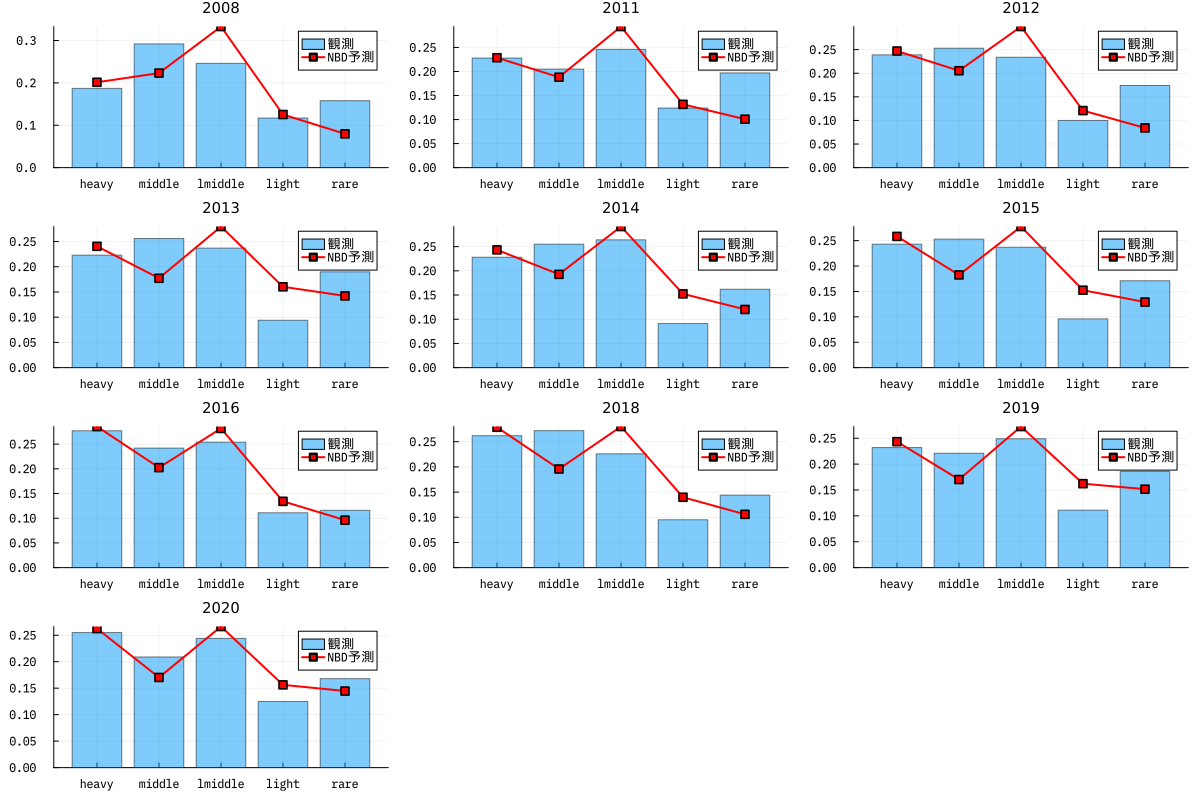

In [6]:
# フィット品質: 観測シェア vs 予測シェア
plts = []
for (i, row) in enumerate(eachrow(df_freq))
    shares = [row.heavy, row.middle, row.lmiddle, row.light, row.rare]
    bins = row.is_post2013 ? bins_post : bins_pre
    r = results.r[i]; α = results.α[i]
    pred, _, _ = bin_probs_given_active(r, α, bins)
    labels = ["heavy", "middle", "lmiddle", "light", "rare"]
    plt = bar(labels, shares, alpha=0.5, label="観測", title="$(row.年)",
              titlefont=font(10))
    plot!(plt, labels, pred, lw=2, marker=:square, color=:red, label="NBD予測")
    push!(plts, plt)
end
plot(plts..., layout=(4, 3), size=(1200, 800))

9×9 DataFrame
 Row │ 年     r         α           E_λ      P_active  M_lift   KL          A_man    M_latent 
     │ Int64  Float64   Float64     Float64  Float64   Float64  Float64     Float64  Float64  
─────┼────────────────────────────────────────────────────────────────────────────────────────
   1 │  2008  0.625865  0.0103898   60.2384  0.943003  1.06044  0.0903376    1580.0   1675.5
   2 │  2011  0.417705  0.00653     63.9671  0.878074  1.13886  0.0985971    1260.0   1434.96
   3 │  2012  0.516733  0.00729741  70.8104  0.921621  1.08504  0.0950932    1110.0   1204.4
   4 │  2013  0.360068  0.00542605  66.3592  0.84745   1.18001  0.0428335     970.0   1144.61
   5 │  2014  0.445437  0.00647172  68.8282  0.894391  1.11808  0.0319297    1150.0   1285.79
   6 │  2015  0.391995  0.0053786   72.8805  0.871317  1.14769  0.0339954    1070.0   1228.03
   7 │  2016  0.513179  0.00620628  82.6871  0.926557  1.07926  0.00921687    940.0   1014.51
   8 │  2018  0.472535  0.0058789   80.378   0

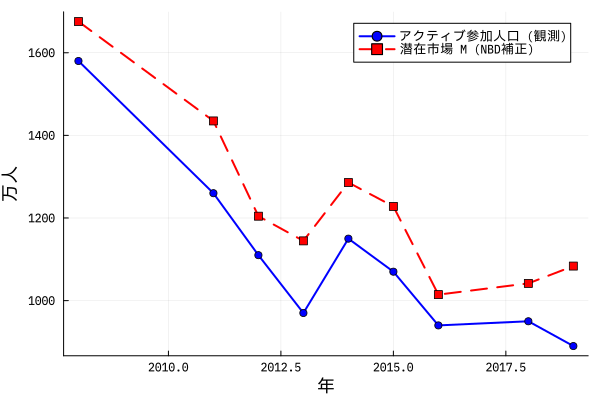

In [7]:
# パチンコ参加人口データと結合し、潜在市場 M_latent(t) を逆算
df_active = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\Pachinko\p-datasets2.csv",
                     DataFrame; missingstring="")
df_active = dropmissing(df_active[:, [:年, :パチンコ参加人口]])
df_active.A_man = df_active.パチンコ参加人口 ./ 10   # 千人→万人

df_merge = innerjoin(results, df_active[:, [:年, :A_man]], on=:年)
df_merge.M_latent = df_merge.A_man .* df_merge.M_lift
println(df_merge)

p1 = plot(df_merge.年, df_merge.A_man, marker=:circle, lw=2, color=:blue,
          label="アクティブ参加人口 (観測)", xlabel="年", ylabel="万人")
plot!(p1, df_merge.年, df_merge.M_latent, marker=:square, lw=2, color=:red,
      label="潜在市場 M (NBD補正)", ls=:dash)
p1

## 解釈ガイド

- **r(t) が減少**: 低頻度層が厚くなっている（分布のバラつき増大）
- **E[λ](t) が減少**: 平均遊戯頻度が下がっている（負の需要要因）
- **P(active)(t) の低下率 vs アクティブ数の低下率**: 乖離があれば市場規模自体の変化
- **M_latent(t) のトレンド**: 真の潜在市場の推移。観測参加人口の低下のどれだけが閾値効果か分かる

## 次ステップ（将来拡張）

1. M_latent(t) を観測値として 3状態 Bass 拡張を再推定 → **真の p₁(t), p₂(t) が分離可能**か検証
2. r(t), α(t) の連続時間ダイナミクスを ODE 化（需要シフトモデル）
3. 頻度シェアを直接尤度に（年ごとに Multinomial）してフル階層ベイズ